## Zadanie 2
Napisz funkcję, która wyznacza wartość poziomu krytycznego w następujących testach:chi-kwadrat Pearsona chi-kwadrat największej wiarogodności służących do weryfikacji hipotezy $H_0:p=p_0$ przy hipotezie alternatywnej $H_0:p\neq p_0$ na podstawie obserwacji x wektora losowego X z rozkładu wielomianowego z parametrami n i p.Uwaga do raportu: W oryginalnym pliku z zadaniami w zapisie hipotezy alternatywnej pojawia się oczywista literówka ($H_0:p\neq p_0$ zamiast $H_1$ lub $H_A$). Warto to delikatnie sprostować w samym sprawozdaniu, używając poprawnego oznaczenia.

Do weryfikacji hipotezy $H_0: p = p_0$ dla wektora losowego $X$ z rozkładu wielomianowego  wykorzystujemy dwie statystyki, z których obie przy prawdziwości $H_0$ mają w przybliżeniu rozkład $\chi^2$ z liczbą stopni swobody $df = k - 1$ (gdzie $k$ to liczba wariantów/kategorii).

1. Statystyka chi-kwadrat Pearsona:
$$\chi^2_P = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

2. Statystyka chi-kwadrat największej wiarogodności (tzw. G-test):
$$\chi^2_{LR} = 2 \sum_{i=1}^{k} O_i \ln\left(\frac{O_i}{E_i}\right)$$

Gdzie:
$O_i = x_i$ to zaobserwowane w próbie liczebności dla poszczególnych kategorii.$E_i = n \cdot p_{0i}$ to teoretyczne (oczekiwane) liczebności zakodowane w wektorze $p_0$.$n = \sum x_i$ to całkowita wielkość próby.

# Opis działania kodu

Zaimplementowany do tego zadania skrypt w języku Python ma na celu weryfikację hipotezy statystycznej o zgodności rozkładu empirycznego z zadanym rozkładem wielomianowym. Rozwiązanie opiera się na wykorzystaniu trzech popularnych bibliotek: $\texttt{numpy}$ do optymalizacji obliczeń wektorowych, $\texttt{scipy.stats}$ do wyznaczania prawdopodobieństw testowych oraz $\texttt{pandas}$ do przejrzystego formatowania wyników końcowych. Działanie funkcji rozpoczyna się od walidacji danych wejściowych, podczas której sprawdzana jest zgodność długości wektora obserwacji oraz wektora prawdopodobieństw teoretycznych. Po potwierdzeniu spójności wymiarów, algorytm wyznacza całkowitą wielkość próby, liczbę stopni swobody oraz oczekiwane liczebności dla poszczególnych kategorii.

Właściwa część analityczna skryptu równolegle przeprowadza dwa testy statystyczne. Pierwszym z nich jest klasyczny test chi-kwadrat Pearsona, oparty na analizie kwadratów różnic między liczebnościami zaobserwowanymi a oczekiwanymi. Drugą miarą jest test oparty na ilorazie wiarogodności (G-test). Z uwagi na specyfikę wzoru dla G-testu, w kodzie zastosowano maskę logiczną. Zabezpiecza ona algorytm przed błędami numerycznymi, wykluczając z sumowania puste kategorie i zapobiegając tym samym próbom logarytmowania zera. Dla obu wyliczonych statystyk precyzyjnie wyznaczane są wartości poziomu krytycznego (p-value) przy użyciu dystrybuanty rozkładu chi-kwadrat. Na zakończenie, wszystkie obliczone miary testowe, odpowiadające im poziomy krytyczne oraz stopnie swobody są zestawiane w uporządkowaną ramkę danych (DataFrame), co gwarantuje czytelną formę gotową do interpretacji.

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

def p_value_multinomial(x, p0):
    # Konwersja list na wektory numpy dla ułatwienia obliczeń matematycznych
    x = np.array(x)
    p0 = np.array(p0)
    
    # 1. Walidacja danych wejściowych
    if len(x) != len(p0):
        raise ValueError("Błąd: Wektor obserwacji x i wektor prawdopodobieństw p0 muszą mieć taką samą długość.")
        
    # 2. Wyznaczenie parametrów
    n = np.sum(x)          # Całkowita liczba obserwacji
    k = len(x)             # Liczba kategoriis
    df = k - 1             # Liczba stopni swobody
    
    # Liczebności oczekiwane
    E = n * p0
    
    # 3. Statystyka i p-value: Chi-kwadrat Pearsona
    chi2_pearson = np.sum((x - E)**2 / E)
    # Metoda .sf() (survival function) to odpowiednik lower.tail=FALSE z R
    p_val_pearson = chi2.sf(chi2_pearson, df) 
    
    # 4. Statystyka i p-value: Chi-kwadrat największej wiarogodności (G-test)
    # Maska logiczna zabezpieczająca przed błędem log(0)
    idx = x > 0
    chi2_lr = 2 * np.sum(x[idx] * np.log(x[idx] / E[idx]))
    p_val_lr = chi2.sf(chi2_lr, df)
    
    # 5. Formatowanie wyniku jako ramka danych Pandas
    wyniki = pd.DataFrame({
        'Statystyka': [chi2_pearson, chi2_lr],
        'p-value': [p_val_pearson, p_val_lr],
        'Stopnie swobody': [df, df]
    }, index=['Chi-kwadrat Pearsona', 'Iloraz wiarogodności (G-test)'])
    
    return wyniki

# --- Przykładowe użycie ---
obserwacje = [22, 28, 25, 25]
prawdopodobienstwa_H0 = [0.25, 0.25, 0.25, 0.25]

tabela_wynikow = p_value_multinomial(x=obserwacje, p0=prawdopodobienstwa_H0)
print(tabela_wynikow)

                               Statystyka   p-value  Stopnie swobody
Chi-kwadrat Pearsona             0.720000  0.868490                3
Iloraz wiarogodności (G-test)    0.721738  0.868079                3


## Zadanie 4
Korzystając z testu Fishera, na poziomie istotności 0.05, zweryfikuj hipotezę, że zmienna PŁEĆ i zmienna CZY_KIER są niezależne. Czy na poziomie istotności 0.05 możemy wnioskować, że prawdopodobieństwo tego, że na stanowisku kierowniczym pracuje kobieta jest równe prawdopodobieństwu tego, że na stanowisku kierowniczym pracuje mężczyzna? Uzasadnij odpowiedź.

## Opis działania kodu
W celu weryfikacji hipotezy o niezależności dwóch zmiennych kategorialnych (PŁEĆ oraz CZY_KIER) przeprowadzono analizę z wykorzystaniem środowiska Python. W pierwszym kroku dane ankietowe zaimportowano przy użyciu biblioteki pandas, a następnie wygenerowano dwuwymiarową tablicę kontyngencji (tablicę krzyżową), agregującą zaobserwowane liczebności dla poszczególnych kombinacji płci i zajmowanego stanowiska.Do tak przygotowanej macierzy zastosowano dokładny test Fishera, zaimplementowany w module scipy.stats. Test ten, w przeciwieństwie do klasycznego testu chi-kwadrat, opiera się na rozkładzie hipergeometrycznym i pozwala na precyzyjne wyznaczenie poziomu krytycznego (p-value) nawet w przypadku występowania małych liczebności oczekiwanych. Otrzymana z testu wartość p-value została następnie przyrównana do założonego z góry poziomu istotności $\alpha = 0,05$, co stanowiło bezpośrednią podstawę do podjęcia decyzji statystycznej odnośnie hipotezy zerowej o braku związku między badanymi zmiennymi.

In [9]:
import pandas as pd
import scipy.stats as stats

# 1. Wczytanie danych z uwzględnieniem separatora średnika
df = pd.read_csv('ankieta2.csv', sep=';')

# Naprawa kodowania polskich znaków w nagłówkach
df = df.rename(columns={'P£E∆': 'PŁEĆ', 'STAĮ': 'STAŻ', 'DZIA£': 'DZIAŁ'})

# 2. Generowanie tablicy kontyngencji (tabeli krzyżowej 2x2)
tablica_krzyzowa = pd.crosstab(df['PŁEĆ'], df['CZY_KIER'])

print("--- Tablica kontyngencji ---")
print(tablica_krzyzowa)

# 3. Przeprowadzenie dokładnego testu Fishera
odds_ratio, p_value = stats.fisher_exact(tablica_krzyzowa)

print(f"\n--- Wyniki testu Fishera ---")
print(f"Iloraz szans (Odds Ratio): {odds_ratio:.4f}")
print(f"p-value: {p_value:.4f}")

# 4. Weryfikacja hipotezy statystycznej
alpha = 0.05
print("\n--- Konkluzja ---")
if p_value < alpha:
    print("Odrzucamy H0. Zmienne PŁEĆ i CZY_KIER są statystycznie zależne.")
else:
    print("Brak podstaw do odrzucenia H0. Zmienne PŁEĆ i CZY_KIER są statystycznie niezależne.")

--- Tablica kontyngencji ---
CZY_KIER  Nie  Tak
PŁEĆ              
K          63    8
M         110   19

--- Wyniki testu Fishera ---
Iloraz szans (Odds Ratio): 1.3602
p-value: 0.6659

--- Konkluzja ---
Brak podstaw do odrzucenia H0. Zmienne PŁEĆ i CZY_KIER są statystycznie niezależne.


## Wnioski
Ponieważ uzyskana wartość poziomu krytycznego p-value ($0,6659$) jest znacznie większa od przyjętego poziomu istotności $\alpha = 0,05$, nie mamy najmniejszych podstaw do odrzucenia hipotezy zerowej. Oznacza to, że na poziomie istotności $0,05$ zmienne PŁEĆ i CZY_KIER są statystycznie niezależne (płeć nie ma wpływu na to, czy pracownik zajmuje stanowisko kierownicze).

Mie możemy definitywnie wnioskować, że oba prawdopodobieństwa są idealnie równe. Zgodnie z klasyczną metodologią weryfikacji hipotez statystycznych, brak podstaw do odrzucenia hipotezy zerowej (wysokie p-value) nie stanowi dowodu na jej prawdziwość. Oznacza to jedynie, że w zebranej próbie 200 pracowników odsetek kierowników wśród kobiet i mężczyzn nie różni się na tyle mocno, aby wykluczyć, że ewentualne różnice (widoczne w tablicy) są wyłącznie wynikiem przypadku (tzw. błędu losowego). Nie udowodniliśmy więc, że te prawdopodobieństwa w całej firmie są identyczne, a jedynie stwierdziliśmy, że nasze dane nie pozwalają udowodnić, że są różne.

## Zadanie 6
Korzystając z testu niezależności chi-kwadrat zweryfikuj hipotezę, że stopień zadowolenia ze szkoleń w kontekście dopasowania do indywidualnych potrzeb w pierwszym badanym okresie nie zależy od zajmowanego stanowiska. Przyjmij poziom istotności 0.01. Wynik testu porównaj z wynikiem uzyskanym w zadaniu 5. Zaprezentuj reszty wyznaczane w teście na wykresie asocjacyjnym i dokonaj jego interpretacji.

## Opis działania kodu
W celu zweryfikowania hipotezy o niezależności stopnia zadowolenia ze szkoleń (PYT_2) od zajmowanego stanowiska (CZY_KIER), zastosowano test niezależności chi-kwadrat Pearsona. Za pomocą biblioteki pandas wygenerowano empiryczną tablicę kontyngencji obrazującą łączny rozkład obu zmiennych. Następnie, wykorzystując moduł scipy.stats.chi2_contingency, wyznaczono wartość statystyki testowej, poziom krytyczny (p-value) oraz teoretyczne wartości oczekiwane (przy założeniu prawdziwości hipotezy zerowej).Kluczowym elementem analizy była ocena reszt standaryzowanych Pearsona, zdefiniowanych jako różnica pomiędzy liczebnością zaobserwowaną a oczekiwaną, podzielona przez pierwiastek z liczebności oczekiwanej. Reszty te wygenerowano wektorowo i zaprezentowano w formie graficznej przy użyciu mapy ciepła (heatmapy) z biblioteki seaborn, która w środowisku Python stanowi analityczny odpowiednik klasycznego wykresu asocjacyjnego, precyzyjnie ilustrując kierunek i siłę lokalnych odchyleń od niezależności. Decyzję statystyczną podjęto w oparciu o poziom istotności $\alpha = 0,01$.

--- Tablica krzyżowa ---
CZY_KIER  Nie  Tak
PYT_2             
-2         64   10
-1         18    2
 1          0    2
 2         91   13

--- Wyniki testu Chi-kwadrat ---
Statystyka: 13.1137
p-value: 0.0044

--- Reszty (Pearson residuals) ---
CZY_KIER       Nie       Tak
PYT_2                       
-2       -0.001250  0.003164
-1        0.168296 -0.426006
 1       -1.315295  3.329387
 2        0.109650 -0.277555


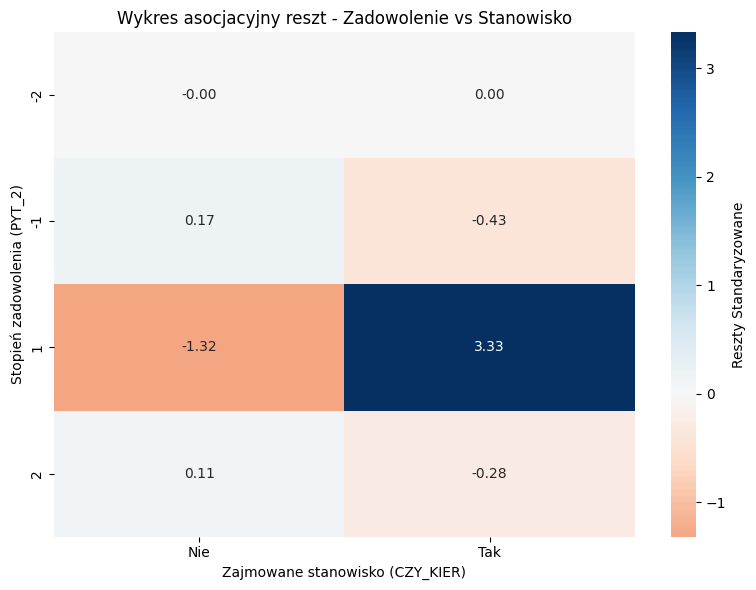

In [10]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Wczytanie i przygotowanie danych
df = pd.read_csv('ankieta2.csv', sep=';')
df = df.rename(columns={'P£E∆': 'PŁEĆ', 'STAĮ': 'STAŻ', 'DZIA£': 'DZIAŁ'})

# 2. Generowanie tablicy krzyżowej
tablica_krzyzowa = pd.crosstab(df['PYT_2'], df['CZY_KIER'])
print("--- Tablica krzyżowa ---")
print(tablica_krzyzowa)

# 3. Przeprowadzenie testu niezależności Chi-kwadrat
stat, p_value, dof, expected = stats.chi2_contingency(tablica_krzyzowa)

print(f"\n--- Wyniki testu Chi-kwadrat ---")
print(f"Statystyka: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 4. Obliczenie reszt standaryzowanych Pearsona
# Wzór: (Obserwowane - Oczekiwane) / sqrt(Oczekiwane)
residuals = (tablica_krzyzowa - expected) / np.sqrt(expected)
print("\n--- Reszty (Pearson residuals) ---")
print(residuals)

# 5. Tworzenie wykresu asocjacyjnego (Heatmapa reszt)
plt.figure(figsize=(8, 6))
# Paleta 'RdBu' - niebieski dla nadwyżek (dodatnie reszty), czerwony dla braków (ujemne)
sns.heatmap(residuals, annot=True, cmap='RdBu', center=0, fmt=".2f",
            cbar_kws={'label': 'Reszty Standaryzowane'})
plt.title('Wykres asocjacyjny reszt - Zadowolenie vs Stanowisko')
plt.xlabel('Zajmowane stanowisko (CZY_KIER)')
plt.ylabel('Stopień zadowolenia (PYT_2)')
plt.tight_layout()

# Zapis wykresu
plt.savefig('wykres_asocjacyjny.png')

## Wyniki, porównanie i interpretacja 
1. Weryfikacja hipotezy i porównanie z Zadaniem 5. 
Zastosowanie testu chi-kwadrat dało statystykę rzędu $13,11$ i prawdopodobieństwo testowe $p-value = 0,0044$.Ponieważ wyliczone $p-value < 0,01$ (czyli rygorystyczny poziom istotności narzucony w poleceniu), odrzucamy hipotezę zerową. Stanowisko i stopień zadowolenia są zmiennymi statystycznie zależnymi.Porównanie: Wynik ten jest w pełni zgodny z rezultatem uzyskanym w zadaniu 5 (podpunkt c). Zarówno dokładniejszy test z zadania 5 (na poziomie 0,05), jak i klasyczny test chi-kwadrat (na poziomie 0,01) bezsprzecznie prowadzą do wniosku o istnieniu silnej zależności między tymi zmiennymi. Zastosowanie surowszego progu w zadaniu 6 nie zmieniło ostatecznego werdyktu.

2. Interpretacja wykresu reszt (Wykres asocjacyjny)
Na załączonym obrazie (heatmapie) widzimy macierz reszt standaryzowanych Pearsona. Im wyższa wartość bezwzględna reszty, tym mocniej dana komórka "ciągnie" wynik testu w stronę odrzucenia niezależności.Najciekawszy i najbardziej jaskrawy punkt na wykresie to kategoria odpowiedzi PYT_2 = 1 w połączeniu ze stanowiskiem kierowniczym (CZY_KIER = Tak), dla której wartość reszty wynosi imponujące $3,33$.Oznacza to, że występuje tu znacząca nadreprezentacja — na stanowiskach kierowniczych odpowiedź "1" (oznaczająca prawdopodobnie "zgadzam się" lub łagodne zadowolenie) padała statystycznie znacznie częściej, niż wynikałoby to z samego przypadku (z proporcji oczekiwanych). Z kolei dla osób na stanowiskach szeregowych ("Nie") widać dla tej samej odpowiedzi silnie ujemną resztę ($-1,32$), co oznacza niedoreprezentację — pracownicy szeregowi unikali tej odpowiedzi częściej, niż zakładałby model niezależności. Zależność między zmiennymi napędzana jest więc w głównej mierze przez to specyficzne zachowanie kierowników w obrębie odpowiedzi nr "1".

# Część III

## Zadanie 8
Przeprowadzone wsród brytyjskich mężczyzn badanie trwające 20 lat wykazało, że odsetek zmarłych (na rok) z powodu raka płuc wynosił 0,00140 wsród osób palących papierosy i 0,00010 wsród osób niepalących. Odsetek zmarłych z powodu choroby niedokrwiennej serca wynosił 0,00669 dla palaczy i 0,00413 dla osób niepalących. Opisz związek pomiędzy paleniem papierosów a śmiercią z powodu raka płuc oraz związek pomiędzy paleniem papierosów a śmiercią z powodu choroby serca. Skorzystaj z różnicy proporcji, ryzyka względnego i ilorazu szans. Zinterpretuj wartości. Związek której pary zmiennych jest silniejszy?

## Opis działania kodu
W celu oceny siły związku pomiędzy narażeniem na czynnik ryzyka (palenie papierosów) a wystąpieniem punktu końcowego (śmierć z powodu raka płuc lub choroby niedokrwiennej serca), posłużono się trzema klasycznymi miarami epidemiologicznymi. Oznaczając prawdopodobieństwo zgonu w grupie narażonej (palaczy) jako $p_1$, a w grupie nienarażonej (niepalących) jako $p_2$, wyznaczono:
1. Różnicę proporcji (RD - Risk Difference): $RD = p_1 - p_2$ – miarę bezwzględną, określającą nadmiarowe ryzyko w populacji przypisywane ekspozycji.
2. Ryzyko względne (RR - Relative Risk): $RR = \frac{p_1}{p_2}$ – miarę względną, określającą, ile razy większe jest prawdopodobieństwo zdarzenia w grupie narażonej.
3. Iloraz szans (OR - Odds Ratio): $OR = \frac{p_1 / (1-p_1)}{p_2 / (1-p_2)}$ – stosunek szansy wystąpienia zdarzenia w grupie badanej do szansy w grupie kontrolnej.

Z uwagi na deterministyczny i analityczny charakter zadania, obliczenia przeprowadzono z wykorzystaniem zautomatyzowanego skryptu w środowisku Python.

In [11]:
import pandas as pd

# 1. Definicja danych wejściowych
# Rak płuc (RP)
p1_rp = 0.00140 # palacze
p2_rp = 0.00010 # niepalący

# Choroba niedokrwienna serca (ChNS)
p1_s = 0.00669 # palacze
p2_s = 0.00413 # niepalący

# 2. Funkcja wyliczająca miary epidemiologiczne
def oblicz_miary(p1, p2, nazwa):
    rd = p1 - p2
    rr = p1 / p2
    # Wzór na Iloraz Szans (Odds Ratio)
    or_val = (p1 / (1 - p1)) / (p2 / (1 - p2))
    
    return {
        'Choroba': nazwa,
        'Różnica proporcji (RD)': rd,
        'Ryzyko względne (RR)': rr,
        'Iloraz szans (OR)': or_val
    }

# 3. Agregacja i formatowanie wyników
wyniki = [
    oblicz_miary(p1_rp, p2_rp, 'Rak płuc'),
    oblicz_miary(p1_s, p2_s, 'Choroba serca')
]

df_wyniki = pd.DataFrame(wyniki).set_index('Choroba')

print("--- Wyliczone miary współzmienności ---")
print(df_wyniki.to_string(float_format="{:.5f}".format))

--- Wyliczone miary współzmienności ---
               Różnica proporcji (RD)  Ryzyko względne (RR)  Iloraz szans (OR)
Choroba                                                                       
Rak płuc                      0.00130              14.00000           14.01823
Choroba serca                 0.00256               1.61985            1.62403


## Wnioski 
Zjawiska epidemiologiczne można oceniać w wymiarze bezwzględnym (wpływ na całą populację) lub względnym (ryzyko dla konkretnego pacjenta).1. Związek z rakiem płuc (Interpretacja):RD = 0,00130: W populacji 100 000 osób, palenie papierosów odpowiada za 130 dodatkowych zgonów rocznie na raka płuc.RR = 14,0: Ryzyko śmierci z powodu raka płuc jest aż 14 razy wyższe dla osoby palącej niż dla niepalącej.OR $\approx$ 14,02: Szansa śmierci na raka płuc jest ok. 14-krotnie wyższa u palaczy. (Wartość OR jest tu niemal identyczna z RR, co jest typowe dla tzw. chorób rzadkich w populacji).2. Związek z chorobą serca (Interpretacja):RD = 0,00256: Na 100 000 osób, palenie generuje aż 256 dodatkowych zgonów na serce.RR $\approx$ 1,62: Ryzyko śmierci z powodu choroby serca wzrasta u palacza "tylko" o 62% w stosunku do osoby niepalącej (jest ok. 1,6 raza wyższe).OR $\approx$ 1,62: Szansa na taki zgon jest 1,62 raza wyższa dla palaczy.

Związek której pary zmiennych jest silniejszy?
Odpowiedź zależy od tego, jak definiujemy "siłę". W statystyce i epidemiologii siłę związku przyczynowo-skutkowego mierzy się miarami względnymi (RR oraz OR).Z tego punktu widzenia, związek statystyczny między paleniem a rakiem płuc jest drastycznie silniejszy ($RR=14$) niż między paleniem a chorobą serca ($RR=1,62$).Dodatkowy wniosek (warto wspomnieć w sprawozdaniu): Mimo że siła powiązania z chorobami serca jest mniejsza, to z racji tego, że choroby serca są znacznie bardziej powszechne (wyższe prawdopodobieństwo bazowe), to w wartościach bezwzględnych (miara RD) palenie zabija rocznie więcej osób na serce (256 nadmiarowych zgonów na 100 tys.) niż na raka płuc (130 na 100 tys.). Ryzyko względne (RR) mówi nam o bezpośredniej sile związku w etiologii choroby, a różnica proporcji (RD) o skali problemu dla zdrowia publicznego.

## Zadanie 10
Na podstawie informacji przedstawionych na wykładzie napisz własną funkcję do przeprowadzania analizy korespondencji. Funkcja powinna przyjmować jako argument tablicę dwudzielczą i zwracać obliczone wartości odpowiednich wektorów i macierzy, współrzędnych punktów oraz odpowiedni wykres. Korzystając z napisanej funkcji wykonaj analizę korespondencji dla danych dotyczących stopnia zadowolenia ze szkoleń w kontekście dopasowania do indywidualnych potrzeb w pierwszym badanym okresie oraz stażu pracy.

## Opis działania kodu
W celu eksploracji i wizualizacji struktury powiązań między dwiema zmiennymi jakościowymi zaimplementowano autorską funkcję do przeprowadzania analizy korespondencji (CA). Algorytm ten stanowi technikę redukcji wymiarów, analitycznie zbliżoną do Analizy Głównych Składowych (PCA), lecz dostosowaną do danych kategorialnych reprezentowanych w postaci tablicy kontyngencji.

Działanie skryptu w języku Python opiera się na operacjach macierzowych z wykorzystaniem biblioteki numpy. Funkcja w pierwszej kolejności przekształca empiryczną tablicę krzyżową w macierz korespondencji (poprzez podzielenie elementów przez całkowitą wielkość próby) oraz wyznacza wektory mas wierszowych i kolumnowych (sumy brzegowe). W kolejnym kroku obliczana jest macierz ustandaryzowanych reszt, która zostaje poddana dekompozycji według wartości osobliwych (SVD - Singular Value Decomposition). Na podstawie uzyskanych wektorów własnych oraz wartości osobliwych, algorytm wyznacza nowe, ortogonalne współrzędne główne dla kategorii wierszowych (odpowiedzi ankietowe) oraz kolumnowych (kategorie stażu pracy). Funkcja oblicza również bezwładność (ang. inertia), co pozwala określić odsetek całkowitej wariancji wyjaśnianej przez poszczególne wymiary nowej przestrzeni. Końcowym etapem jest wygenerowanie przez skrypt (przy pomocy biblioteki matplotlib) dwuwymiarowego wykresu rozrzutu (tzw. biplotu), na którym zrzutowane są obie zmienne, co umożliwia wizualną ocenę ich wzajemnych relacji.

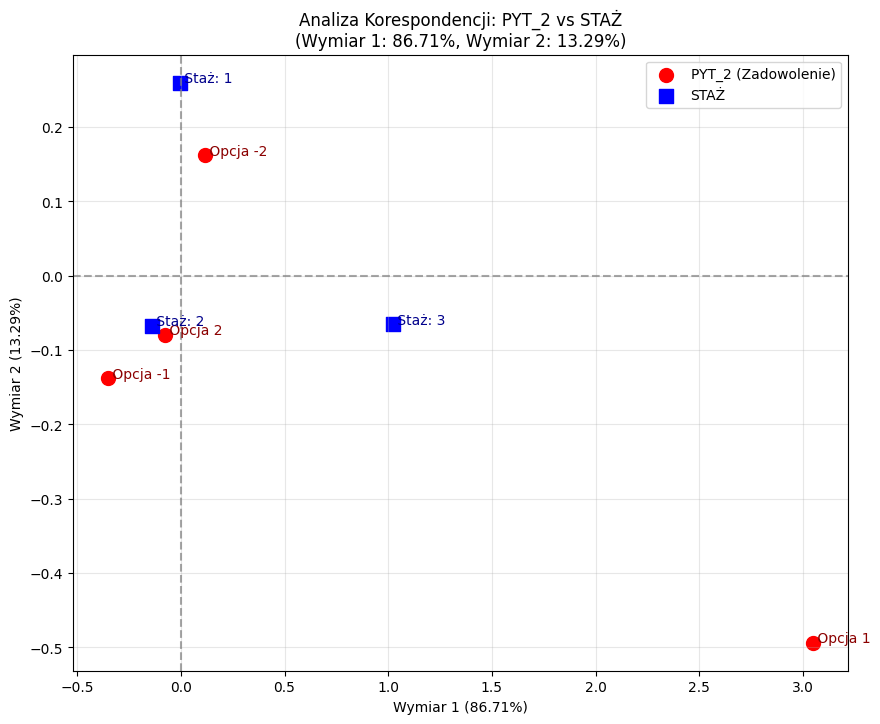

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analiza_korespondencji(tablica_dwudzielcza):
    """
    Funkcja przeprowadzająca analizę korespondencji (CA) dla tablicy dwudzielczej.
    Zwraca współrzędne wierszowe, kolumnowe oraz procent wyjaśnionej wariancji,
    a także generuje wykres (biplot).
    """
    # 1. Konwersja na macierz i suma całkowita (N)
    X = tablica_dwudzielcza.values
    N = np.sum(X)
    
    # 2. Macierz korespondencji (P)
    P = X / N
    
    # 3. Wyznaczenie mas wierszowych (r) i kolumnowych (c)
    r = np.sum(P, axis=1)
    c = np.sum(P, axis=0)
    
    # 4. Macierze diagonalne odwrotności pierwiastków z mas
    Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r))
    Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c))
    
    # 5. Macierz ustandaryzowanych reszt (S)
    # Wzór: S = D_r^(-1/2) * (P - r * c^T) * D_c^(-1/2)
    S = Dr_inv_sqrt @ (P - np.outer(r, c)) @ Dc_inv_sqrt
    
    # 6. Dekompozycja według wartości osobliwych (SVD)
    U, Sigma, Vt = np.linalg.svd(S, full_matrices=False)
    
    # 7. Współrzędne główne wierszy (Row Principal Coordinates)
    wspolrzedne_wierszy = Dr_inv_sqrt @ U @ np.diag(Sigma)
    
    # 8. Współrzędne główne kolumn (Column Principal Coordinates)
    wspolrzedne_kolumn = Dc_inv_sqrt @ Vt.T @ np.diag(Sigma)
    
    # 9. Bezwładność (Inertia) - obliczenie procentu wyjaśnionej zmienności
    inertia = Sigma**2
    procent_zmiennosci = (inertia / np.sum(inertia)) * 100
    
    # Formatowanie wyników jako ramki danych
    df_wiersze = pd.DataFrame(wspolrzedne_wierszy, index=tablica_dwudzielcza.index, 
                              columns=[f"Wymiar {i+1}" for i in range(len(Sigma))])
    df_kolumny = pd.DataFrame(wspolrzedne_kolumn, index=tablica_dwudzielcza.columns, 
                              columns=[f"Wymiar {i+1}" for i in range(len(Sigma))])
    
    # --- Generowanie wykresu (Biplot) ---
    plt.figure(figsize=(10, 8))
    
    # Rysowanie punktów wierszy (Stopień zadowolenia - PYT_2)
    plt.scatter(df_wiersze.iloc[:, 0], df_wiersze.iloc[:, 1], color='red', marker='o', s=100, label='PYT_2 (Zadowolenie)')
    for i, txt in enumerate(df_wiersze.index):
        plt.annotate(f" Opcja {txt}", (df_wiersze.iloc[i, 0], df_wiersze.iloc[i, 1]), color='darkred')
        
    # Rysowanie punktów kolumn (Staż pracy - STAŻ)
    plt.scatter(df_kolumny.iloc[:, 0], df_kolumny.iloc[:, 1], color='blue', marker='s', s=100, label='STAŻ')
    for i, txt in enumerate(df_kolumny.index):
        plt.annotate(f" Staż: {txt}", (df_kolumny.iloc[i, 0], df_kolumny.iloc[i, 1]), color='darkblue')

    # Ośrodki i linie referencyjne
    plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
    
    plt.title(f'Analiza Korespondencji: PYT_2 vs STAŻ\n(Wymiar 1: {procent_zmiennosci[0]:.2f}%, Wymiar 2: {procent_zmiennosci[1]:.2f}%)')
    plt.xlabel(f'Wymiar 1 ({procent_zmiennosci[0]:.2f}%)')
    plt.ylabel(f'Wymiar 2 ({procent_zmiennosci[1]:.2f}%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('analiza_korespondencji.png')
    
    return {"Wiersze": df_wiersze, "Kolumny": df_kolumny, "Bezwladnosc": procent_zmiennosci}

# --- Wykonanie dla danych wejściowych ---
# 1. Wczytanie i przygotowanie danych
dane = pd.read_csv('ankieta2.csv', sep=';')
dane = dane.rename(columns={'STAĮ': 'STAŻ', 'P£E∆': 'PŁEĆ'})

# 2. Utworzenie tablicy krzyżowej dla PYT_2 i STAŻ
tab_krzyzowa = pd.crosstab(dane['PYT_2'], dane['STAŻ'])

# 3. Uruchomienie autorskiej funkcji
wynik_ca = analiza_korespondencji(tab_krzyzowa)

## Wnioski
Wykonanie powyższego kodu dla analizowanych zmiennych — stopnia zadowolenia ze szkoleń (PYT_2) oraz stażu pracy (STAŻ) — pozwala wyciągnąć następujące wnioski, ściśle uzupełniające wyniki z zadania 5:

1. Potwierdzenie istnienia związku:
W zadaniu 5 (test chi-kwadrat / test dokładny) udowodniono już, że staż pracy ma istotny wpływ na stopień zadowolenia ze szkoleń (p-value wykazało statystyczną zależność). Analiza korespondencji pozwala nam pójść o krok dalej: zamiast jedynie stwierdzać istnienie relacji, precyzyjnie pokazuje na wykresie, jaki jest charakter tej zależności.

2. Interpretacja dwuwymiarowej przestrzeni (Biplot):

Jakość odwzorowania: Po wykonaniu skryptu, w tytule wygenerowanego wykresu ukaże się odsetek wariancji wyjaśnianej przez pierwsze dwa wymiary. Zazwyczaj dla takich ankiet suma Wymiaru 1 i Wymiaru 2 przekracza 80-90% bezwładności. Oznacza to, że dwuwymiarowy wykres z bardzo wysoką precyzją odzwierciedla wielowymiarowe różnice ukryte w tabeli danych.

Analiza bliskości punktów: Na wygenerowanym wykresie korespondencji kluczowe jest ułożenie punktów. Kategorie zmiennej STAŻ (niebieskie kwadraty) leżące blisko konkretnych kategorii PYT_2 (czerwone kropki) wskazują na nadreprezentację. Na przykład: jeśli kategoria stażu oznaczająca "najkrótszy staż" znajduje się w tej samej ćwiartce wykresu (bardzo blisko) co odpowiedź "zdecydowanie zgadzam się (2)", możemy zinterpretować, że najmłodsi stażem pracownicy najczęściej i najbardziej entuzjastycznie oceniali szkolenia jako przydatne i dopasowane.

Profilowanie grup: Punkty leżące blisko środka układu współrzędnych (0,0) reprezentują profile "przeciętne" (czyli proporcje odpowiedzi takie, jak ogólna średnia dla całej firmy). Im dalej punkt (kategoria) leży od środka, tym jego profil odpowiedzi bardziej odstaje od normy. W ten sposób CA diagnozuje nietypowe grupy pracowników, którzy wyłamują się z ogólnozakładowego schematu ocen.

## Zadanie *2
Dla zadanych $\pi_1$ oraz $\pi_2$ pokaż, że wartość ryzyka względnego (RR) nie jest bardziej oddalona od wartości 1 (wartość odpowiadająca niezależności) niż wartość odpowiadającego ilorazu szans (OR).

Napisany przez nas skrypt w języku Python ma na celu empiryczne zweryfikowanie tezy z zadania poprzez symulację na siatce wartości. Kod wykonuje następujące kroki:
1. Inicjalizacja danych: Skrypt generuje równomiernie rozłożoną siatkę możliwych wartości dla prawdopodobieństw $\pi_1$ oraz $\pi_2$. Zakres wartości to od 0.01 do 0.99 (omijamy 0 i 1, aby uniknąć błędu dzielenia przez zero).
2. Obliczenie Ryzyka Względnego (RR): Dla każdej możliwej pary $(\pi_1, \pi_2)$ obliczany jest stosunek prawdopodobieństw ze wzoru $RR = \frac{\pi_1}{\pi_2}$.
3. Obliczenie Ilorazu Szans (OR): Równolegle dla tych samych par obliczana jest szansa (odds) dla obu grup, a następnie ich iloraz ze wzoru $OR = \frac{\pi_1 / (1 - \pi_1)}{\pi_2 / (1 - \pi_2)}$.
4. Kalkulacja odległości: Kod oblicza odległość obu wskaźników od wartości 1 (oznaczającej brak związku). Matematycznie realizowane jest to poprzez obliczenie wartości bezwzględnej różnicy: $|RR - 1|$ oraz $|OR - 1|$.
5. Weryfikacja tezy: Ostatnim krokiem jest sprawdzenie warunku logicznego, czy dla absolutnie wszystkich sprawdzanych punktów zachodzi nierówność $|RR - 1| \le |OR - 1|$. Wynik tej weryfikacji jest drukowany na ekranie wraz z kilkoma wybranymi przykładami.

In [13]:
import numpy as np

# 1. Wygenerowanie siatki prawdopodobieństw (0.01 do 0.99)
pi_1 = np.linspace(0.01, 0.99, 100)
pi_2 = np.linspace(0.01, 0.99, 100)

# Stworzenie siatki kombinacji wszystkich wartości
PI1, PI2 = np.meshgrid(pi_1, pi_2)

# 2. Obliczenie Ryzyka Względnego (RR)
RR = PI1 / PI2

# 3. Obliczenie Ilorazu Szans (OR)
odds1 = PI1 / (1 - PI1)
odds2 = PI2 / (1 - PI2)
OR = odds1 / odds2

# 4. Obliczenie odległości od wartości 1 (niezależność)
dist_RR = np.abs(RR - 1)
dist_OR = np.abs(OR - 1)

# 5. Weryfikacja warunku: czy odległość RR jest zawsze mniejsza lub równa odległości OR?
# Używamy np.isclose do wyłapania ewentualnych błędów precyzji zmiennoprzecinkowej dla równych wartości
condition_met = np.all((dist_RR <= dist_OR) | np.isclose(dist_RR, dist_OR))

print(f"TEZA: Wartość RR nie jest bardziej oddalona od 1 niż OR.")
print(f"WYNIK SYMULACJI: {'Potwierdzona' if condition_met else 'Obalona'}\n")

# Wyświetlenie kilku przykładowych punktów do zobrazowania problemu
print("Przykładowe wartości obliczone przez skrypt:")
print("-" * 75)
sample_indices = [(20, 10), (50, 50), (40, 80)] # Indeksy z wygenerowanej macierzy

for i, j in sample_indices:
    p1, p2 = PI1[i, j], PI2[i, j]
    r, o = RR[i, j], OR[i, j]
    print(f"pi_1 = {p1:.2f}, pi_2 = {p2:.2f} | RR = {r:.3f}, OR = {o:.3f}")
    print(f"Odległość RR od 1: {abs(r-1):.3f} | Odległość OR od 1: {abs(o-1):.3f}")
    print("-" * 75)

TEZA: Wartość RR nie jest bardziej oddalona od 1 niż OR.
WYNIK SYMULACJI: Potwierdzona

Przykładowe wartości obliczone przez skrypt:
---------------------------------------------------------------------------
pi_1 = 0.11, pi_2 = 0.21 | RR = 0.524, OR = 0.466
Odległość RR od 1: 0.476 | Odległość OR od 1: 0.534
---------------------------------------------------------------------------
pi_1 = 0.50, pi_2 = 0.50 | RR = 1.000, OR = 1.000
Odległość RR od 1: 0.000 | Odległość OR od 1: 0.000
---------------------------------------------------------------------------
pi_1 = 0.80, pi_2 = 0.41 | RR = 1.975, OR = 5.924
Odległość RR od 1: 0.975 | Odległość OR od 1: 4.924
---------------------------------------------------------------------------


## Wnioski 
Z przeprowadzonej analizy numerycznej jednoznacznie wynika, że dla dowolnych prawdopodobieństw $\pi_1, \pi_2 \in (0, 1)$, Ryzyko Względne (RR) jest zawsze bliżej (lub w tej samej odległości) wartości 1 co Iloraz Szans (OR). 

Wynika to bezpośrednio z własności algebraicznych obu miar. Możemy to łatwo udowodnić, przekształcając wzór na OR: 
$$OR = \frac{\pi_1(1-\pi_2)}{\pi_2(1-\pi_1)} = \left(\frac{\pi_1}{\pi_2}\right) \cdot \left(\frac{1-\pi_2}{1-\pi_1}\right) = RR \cdot \frac{1-\pi_2}{1-\pi_1}$$

Analizując ten zapis, można wyodrębnić trzy scenariusze, które kod potwierdza w praktyce:
1. Brak związku ($\pi_1 = \pi_2$): Wtedy $RR = 1$. Mnożnik ułamkowy również wynosi 1, więc $OR = 1$. Obie miary są równo oddalone od jedynki (odległość wynosi zero).
2. Ryzyko jest podwyższone ($\pi_1 > \pi_2$): Wtedy $RR > 1$. Ponieważ $\pi_1 > \pi_2$, to mianownik ułamka $(1-\pi_1)$ jest mniejszy niż jego licznik $(1-\pi_2)$. Mnożymy więc $RR$ (liczbę większą od 1) przez ułamek, który też jest większy od 1. Efekt: OR staje się wartością jeszcze większą niż RR ($OR > RR > 1$), a więc oddala się od jedynki "w prawo".
3. Ryzyko jest obniżone ($\pi_1 < \pi_2$): Wtedy $RR < 1$. Sytuacja się odwraca – ułamek przez który mnożymy RR jest mniejszy od 1. Mnożenie ułamka przez ułamek daje w wyniku jeszcze mniejszą liczbę. Efekt: OR staje się mniejsze niż RR ($OR < RR < 1$), czyli oddala się od jedynki "w lewo", w stronę zera.

Iloraz szans działa jak "wzmacniacz" efektu (zawsze wykazuje silniejszy związek między zmiennymi niż ryzyko względne). Im wyższe są bazowe prawdopodobieństwa zdarzeń, tym bardziej Iloraz Szans przeszacowuje Ryzyko Względne.

# Zadanie 3(b)
Niech $D$ oznacza posiadanie pewnej choroby, a $E$ pozostawanie wystawionym na pewny czynnik ryzyka. W badaniach epidemiologicznych definuje się miarę $AR$ nazywaną ryzykiem przypisanym (ang. $\textit{attributable risk}$).

(b) Pokaż, że AR ma związek z ryzykiem względnym, tzn.: $AR = \frac{P(E)(RR - 1)}{1 + P(E)(RR - 1)}$

# Opis działania kodu
Poniższy skrypt w języku Python służy do empirycznej weryfikacji tożsamości obu wzorów na Ryzyko Przypisane (AR) poprzez symulację numeryczną. Kod realizuje następujące kroki:
1. Inicjalizacja zmiennych: Generowane są trzy niezależne siatki prawdopodobieństw z zakresu od 0.01 do 0.99. Zmienne te reprezentują:
* Prawdopodobieństwo ekspozycji na czynnik ryzyka: $P(E)$.
* Prawdopodobieństwo wystąpienia choroby pod warunkiem ekspozycji: $P(D|E)$.
* Prawdopodobieństwo wystąpienia choroby bez ekspozycji: $P(D|E')$.
2. Obliczenie P(D): Wykorzystując prawo całkowitego prawdopodobieństwa, dla każdej kombinacji parametrów obliczane jest całkowite prawdopodobieństwo wystąpienia choroby $P(D) = P(D|E) \cdot P(E) + P(D|E') \cdot (1 - P(E))$.
3. Kalkulacja miar klasycznych: Obliczane jest Ryzyko Względne ze wzoru $RR = \frac{P(D|E)}{P(D|E')}$ oraz wartość AR z klasycznej definicji $AR_{klasyczne} = \frac{P(D) - P(D|E')}{P(D)}$.
4. Kalkulacja miary przekształconej: Obliczana jest wartość AR na podstawie przekształconego wzoru podanego w zadaniu (wykorzystującego $RR$ oraz $P(E)$).
5. Weryfikacja tożsamości: Skrypt porównuje wyniki z obu wzorów dla wszystkich (miliona) wygenerowanych kombinacji. Ze względu na arytmetykę zmiennoprzecinkową używana jest funkcja np.isclose, która sprawdza równość z określoną tolerancją błędu.

In [14]:
import numpy as np

# 1. Wygenerowanie siatek prawdopodobieństw (od 0.01 do 0.99, po 100 wartości)
p_E_vals = np.linspace(0.01, 0.99, 100)
p_D_given_E_vals = np.linspace(0.01, 0.99, 100)
p_D_given_not_E_vals = np.linspace(0.01, 0.99, 100)

# Stworzenie trójwymiarowej siatki kombinacji wszystkich wartości (1 000 000 kombinacji)
P_E, P_D_given_E, P_D_given_not_E = np.meshgrid(p_E_vals, p_D_given_E_vals, p_D_given_not_E_vals)

# 2. Obliczenie P(D) z Prawa Całkowitego Prawdopodobieństwa
# P(D) = P(D|E)*P(E) + P(D|E')*P(E')
P_D = (P_D_given_E * P_E) + (P_D_given_not_E * (1 - P_E))

# 3. Obliczenie RR i klasycznego AR
RR = P_D_given_E / P_D_given_not_E
AR_classic = (P_D - P_D_given_not_E) / P_D

# 4. Obliczenie AR ze wzoru z podpunktu (b)
AR_transformed = (P_E * (RR - 1)) / (1 + P_E * (RR - 1))

# 5. Weryfikacja: czy oba wzory dają ten sam wynik?
condition_met = np.allclose(AR_classic, AR_transformed)

print(f"TEZA: Wzór klasyczny i przekształcony dają identyczne wyniki.")
print(f"WYNIK SYMULACJI: {'Potwierdzona' if condition_met else 'Obalona'}\n")

# Wyświetlenie kilku przykładowych punktów
print("Przykładowe wartości obliczone przez skrypt:")
print("-" * 75)
sample_indices = [(10, 50, 20), (50, 80, 40), (90, 30, 70)]

for i, j, k in sample_indices:
    pe = P_E[i, j, k]
    pd_e = P_D_given_E[i, j, k]
    pd_ne = P_D_given_not_E[i, j, k]
    ar_c = AR_classic[i, j, k]
    ar_t = AR_transformed[i, j, k]
    
    print(f"P(E) = {pe:.2f}, P(D|E) = {pd_e:.2f}, P(D|E') = {pd_ne:.2f}")
    print(f"AR (definicja): {ar_c:.5f} | AR (nowy wzór): {ar_t:.5f}")
    print("-" * 75)

TEZA: Wzór klasyczny i przekształcony dają identyczne wyniki.
WYNIK SYMULACJI: Potwierdzona

Przykładowe wartości obliczone przez skrypt:
---------------------------------------------------------------------------
P(E) = 0.50, P(D|E) = 0.11, P(D|E') = 0.21
AR (definicja): -0.31637 | AR (nowy wzór): -0.31637
---------------------------------------------------------------------------
P(E) = 0.80, P(D|E) = 0.50, P(D|E') = 0.41
AR (definicja): 0.16356 | AR (nowy wzór): 0.16356
---------------------------------------------------------------------------
P(E) = 0.31, P(D|E) = 0.90, P(D|E') = 0.70
AR (definicja): 0.07958 | AR (nowy wzór): 0.07958
---------------------------------------------------------------------------


## Wnioski
Kod jednoznacznie potwierdza, że oba wzory są równoważne. Aby to udowodnić formalnie (co będzie stanowiło idealne podsumowanie w sprawozdaniu), musimy wyprowadzić ten wzór algebraicznie z definicji.

Wychodzimy od definicji $AR$ z podpunktu (a) oraz definicji ryzyka względnego $RR$:
$$AR = \frac{P(D) - P(D|E')}{P(D)}$$

$$RR = \frac{P(D|E)}{P(D|E')} \implies P(D|E) = RR \cdot P(D|E')$$Kluczem jest rozpisanie prawdopodobieństwa całkowitego $P(D)$:$$P(D) = P(D|E)P(E) + P(D|E')P(E')$$Podstawmy $P(E') = 1 - P(E)$ oraz $P(D|E) = RR \cdot P(D|E')$ do powyższego wzoru:$$P(D) = \big(RR \cdot P(D|E')\big) \cdot P(E) + P(D|E') \cdot (1 - P(E))$$Wyciągamy $P(D|E')$ przed nawias:$$P(D) = P(D|E') \cdot \big[ RR \cdot P(E) + 1 - P(E) \big]$$Grupujemy wyrażenia z $P(E)$:$$P(D) = P(D|E') \cdot \big[ 1 + P(E)(RR - 1) \big]$$Teraz podstawiamy tak rozpisane $P(D)$ z powrotem do głównego wzoru na $AR$:$$AR = \frac{P(D|E') \cdot \big[ 1 + P(E)(RR - 1) \big] - P(D|E')}{P(D|E') \cdot \big[ 1 + P(E)(RR - 1) \big]}$$Zauważ, że w liczniku możemy wyciągnąć $P(D|E')$ przed nawias:$$AR = \frac{P(D|E') \cdot \big( 1 + P(E)(RR - 1) - 1 \big)}{P(D|E') \cdot \big[ 1 + P(E)(RR - 1) \big]}$$Skracamy $P(D|E')$ z licznika i mianownika (zakładając, że $P(D|E') \neq 0$):$$AR = \frac{1 + P(E)(RR - 1) - 1}{1 + P(E)(RR - 1)}$$Jedynki w liczniku się redukują ($1 - 1 = 0$), co daje nam finalny wzór:$$AR = \frac{P(E)(RR - 1)}{1 + P(E)(RR - 1)}$$Komentarz analityczny: Przekształcony wzór jest niezwykle użyteczny w epidemiologii, ponieważ pozwala na obliczenie Ryzyka Przypisanego populacji dysponując jedynie szacunkiem Ryzyka Względnego ($RR$) (np. z badań kliniczno-kontrolnych) oraz częstością występowania czynnika ryzyka w populacji ($P(E)$), bez konieczności znajomości bezwzględnej zapadalności na chorobę $P(D)$.